# Multi-Class Pneumonia Classification using EfficientNet-B0 with Explainable AI (Grad-CAM)

## Notebook 02: Dataset Preparation

### Objectives

This notebook prepares the original Chest X-ray dataset for multi-class pneumonia classification.

The main objectives are:

- Load the original Chest X-ray dataset
- Separate bacterial and viral pneumonia images
- Merge all dataset splits
- Perform a stratified 70/15/15 train-validation-test split
- Create the processed dataset
- Verify the processed dataset

## Import Required Libraries

In [20]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


## Reproducibility

Set a fixed random seed to ensure reproducible dataset preparation.

In [21]:
# ============================================================
# Set Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random Seed : {SEED}")

Random Seed : 42


## Dataset Paths

Define the original dataset location and the destination directory for the processed dataset.

In [22]:
# ============================================================
# Dataset Paths
# ============================================================

ORIGINAL_DATASET = Path(
    "/mnt/g/Research paper/Research paper/dataset of pneomunia/chest_xray"
)

PROCESSED_DATASET = Path(
    "/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/dataset/processed_dataset"
)

print("Original Dataset")
print(ORIGINAL_DATASET)

print("\nProcessed Dataset")
print(PROCESSED_DATASET)

Original Dataset
/mnt/g/Research paper/Research paper/dataset of pneomunia/chest_xray

Processed Dataset
/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/dataset/processed_dataset


## Create Processed Dataset Directory

Create the destination directory if it does not already exist.

In [23]:
# ============================================================
# Create Processed Dataset Directory
# ============================================================

PROCESSED_DATASET.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed dataset directory is ready.")
print(PROCESSED_DATASET)

Processed dataset directory is ready.
/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/dataset/processed_dataset


## Build Dataset Metadata

Collect all images from the original dataset and create a metadata table containing:

- Image path
- Original dataset split
- Multi-class label (NORMAL, BACTERIA, VIRUS)

The metadata will be used for stratified dataset splitting.

In [24]:
# ============================================================
# Build Dataset Metadata
# ============================================================

records = []

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

original_splits = ["train", "val", "test"]

for split in original_splits:

    split_path = ORIGINAL_DATASET / split

    for class_dir in split_path.iterdir():

        if not class_dir.is_dir():
            continue

        original_class = class_dir.name

        for image_path in class_dir.iterdir():

            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            filename = image_path.name.lower()

            # ---------- Multi-Class Label ----------

            if original_class == "NORMAL":
                label = "NORMAL"

            elif "bacteria" in filename:
                label = "BACTERIA"

            elif "virus" in filename:
                label = "VIRUS"

            else:
                continue

            records.append({
                "image_path": image_path,
                "filename": image_path.name,
                "original_split": split,
                "label": label
            })

print(f"Total Images Collected : {len(records):,}")

Total Images Collected : 5,856


## Create Metadata DataFrame

Convert the collected image information into a Pandas DataFrame for further processing.

In [25]:
# ============================================================
# Create Metadata DataFrame
# ============================================================

metadata = pd.DataFrame(records)

print(metadata.shape)

metadata.head()

(5856, 4)


,image_path,filename,original_split,label
0,/mnt/g/Research paper/Research paper/dataset o...,IM-0115-0001.jpeg,train,NORMAL
1,/mnt/g/Research paper/Research paper/dataset o...,IM-0117-0001.jpeg,train,NORMAL
2,/mnt/g/Research paper/Research paper/dataset o...,IM-0119-0001.jpeg,train,NORMAL
3,/mnt/g/Research paper/Research paper/dataset o...,IM-0122-0001.jpeg,train,NORMAL
4,/mnt/g/Research paper/Research paper/dataset o...,IM-0125-0001.jpeg,train,NORMAL


## Verify Class Distribution

Check the number of images in each class before dataset splitting.

In [26]:
# ============================================================
# Class Distribution
# ============================================================

class_counts = (
    metadata["label"]
    .value_counts()
    .sort_index()
)

display(class_counts)

label
BACTERIA    2780
NORMAL      1583
VIRUS       1493
Name: count, dtype: int64

## Visualize Class Distribution

Visualize the number of images in each class.

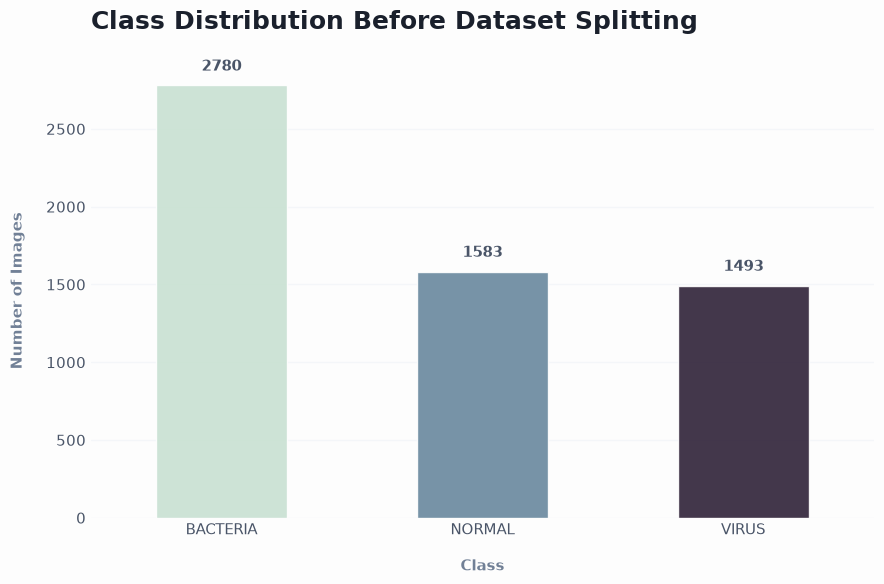

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Silence any unnecessary warnings completely
warnings.filterwarnings("ignore", category=FutureWarning)

# Set clean white background
sns.set_theme(style="white")

# Create figure with a crisp layout
fig, ax = plt.subplots(figsize=(9, 6), facecolor="#fdfdfd")
ax.set_facecolor("#fdfdfd")

# Modern soft gradient palette
colors = sns.color_palette("ch:start=.5,rot=-.55", len(class_counts))

# Generate the bar plot (Fixed: added hue and legend=False to fix the warning)
ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette=colors,
    legend=False,
    edgecolor=None,     
    width=0.5,          
    alpha=0.9           
)

# Style and position the bar labels
for container in ax.containers:
    ax.bar_label(
        container, 
        padding=8,      
        fontsize=11, 
        weight="bold",  # Fixed: changed from semibold to bold to prevent font warning
        color="#4a5568" 
    )

# Premium Typography Setup
plt.title(
    "Class Distribution Before Dataset Splitting",
    fontsize=18,
    weight="bold",
    pad=25,
    color="#1a202c",    
    loc="left"          
)

plt.xlabel("Class", fontsize=11, labelpad=15, weight="bold", color="#718096")
plt.ylabel("Number of Images", fontsize=11, labelpad=15, weight="bold", color="#718096")

# Style the axis ticks
plt.xticks(fontsize=11, color="#4a5568")
plt.yticks(fontsize=11, color="#4a5568")

# Remove all outer box borders completely
sns.despine(left=True, bottom=True)

# Add very subtle, clean horizontal lines
ax.yaxis.grid(True, linestyle="-", alpha=0.3, color="#e2e8f0")
ax.xaxis.grid(False)

# Remove the tick marks themselves, keeping just the labels
ax.tick_params(axis='both', which='both', length=0)

# Render cleanly
plt.tight_layout()
plt.show()


## Stratified Train-Validation-Test Split

Split the complete dataset into training, validation, and testing sets using a stratified 70/15/15 ratio while preserving the class distribution.

In [28]:
# ============================================================
# Stratified 70 / 15 / 15 Split
# ============================================================

# Step 1 : 70% Train | 30% Temporary
train_df, temp_df = train_test_split(
    metadata,
    test_size=0.30,
    stratify=metadata["label"],
    random_state=SEED,
    shuffle=True
)

# Step 2 : 15% Validation | 15% Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
    shuffle=True
)

print("=" * 60)
print(f"Train Images      : {len(train_df):,}")
print(f"Validation Images : {len(val_df):,}")
print(f"Test Images       : {len(test_df):,}")
print(f"Total Images      : {len(metadata):,}")
print("=" * 60)

Train Images      : 4,099
Validation Images : 878
Test Images       : 879
Total Images      : 5,856


## Verify Dataset Split

In [29]:
# ============================================================
# Verify Dataset Split
# ============================================================

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [
        len(train_df),
        len(val_df),
        len(test_df)
    ]
})

split_summary["Percentage"] = (
    split_summary["Images"] /
    split_summary["Images"].sum() * 100
).round(2)

split_summary

,Split,Images,Percentage
0,Train,4099,70.00
1,Validation,878,14.99
2,Test,879,15.01


## Class Distribution After Splitting

In [30]:
# ============================================================
# Class Distribution After Splitting
# ============================================================

distribution = pd.concat([
    train_df["label"].value_counts().rename("Train"),
    val_df["label"].value_counts().rename("Validation"),
    test_df["label"].value_counts().rename("Test")
], axis=1).fillna(0).astype(int)

distribution = distribution.sort_index()

distribution

,Train,Validation,Test
label,,,
BACTERIA,1946,417,417
NORMAL,1108,237,238
VIRUS,1045,224,224


## Visualize Dataset Split

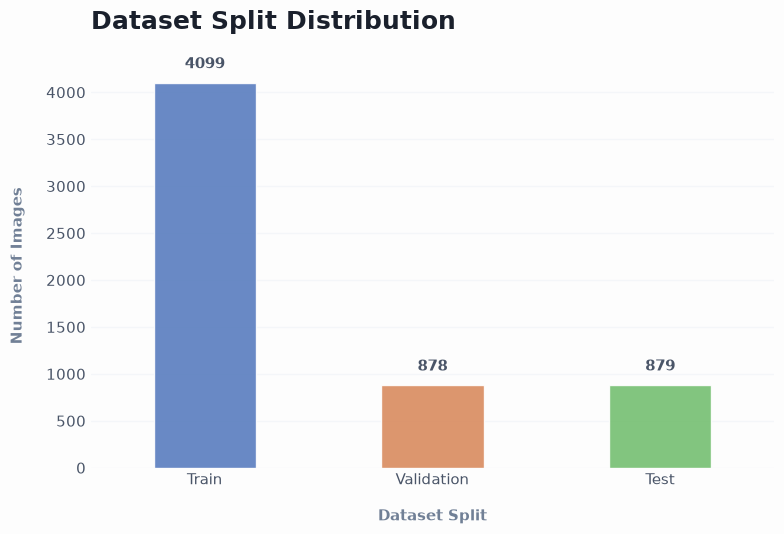

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean white background
sns.set_theme(style="white")

# Create figure with a crisp layout
fig, ax = plt.subplots(figsize=(8, 5.5), facecolor="#fdfdfd")
ax.set_facecolor("#fdfdfd")

# Clean, distinct modern palette for Train, Val, and Test
# You can also use "Set2", "Pastel1", or custom hex colors
colors = sns.color_palette("muted", 3)

# Generate the bar plot
ax = sns.barplot(
    data=split_summary,
    x="Split",
    y="Images",
    hue="Split",
    palette=colors,
    legend=False,
    edgecolor=None,     # No harsh borders around bars
    width=0.45,         # Thinner, more elegant bars
    alpha=0.9           # Softens the color opacity slightly
)

# Automatically add value labels on top of the bars
for container in ax.containers:
    ax.bar_label(
        container, 
        padding=8,      # More breathing room above the bar
        fontsize=11, 
        weight="bold",  # Safe bold weight to prevent system font errors
        color="#4a5568" # Soft charcoal color
    )

# Premium Typography Setup
plt.title(
    "Dataset Split Distribution",
    fontsize=18,
    weight="bold",
    pad=25,
    color="#1a202c",    # Deep off-black
    loc="left"          # Left-aligned for a modern, editorial UI feel
)

# Axis Configuration
plt.xlabel("Dataset Split", fontsize=11, labelpad=15, weight="bold", color="#718096")
plt.ylabel("Number of Images", fontsize=11, labelpad=15, weight="bold", color="#718096")

# Style the axis ticks
plt.xticks(fontsize=11, color="#4a5568")
plt.yticks(fontsize=11, color="#4a5568")

# Remove all outer box borders completely
sns.despine(left=True, bottom=True)

# Add very subtle, clean horizontal lines
ax.yaxis.grid(True, linestyle="-", alpha=0.3, color="#e2e8f0")
ax.xaxis.grid(False)

# Remove the tick marks themselves, keeping just the labels
ax.tick_params(axis='both', which='both', length=0)

# Render cleanly
plt.tight_layout()
plt.show()


In [32]:
distribution

,Train,Validation,Test
label,,,
BACTERIA,1946,417,417
NORMAL,1108,237,238
VIRUS,1045,224,224


In [33]:
distribution.reset_index().columns

Index(['label', 'Train', 'Validation', 'Test'], dtype='str')

In [34]:
# ============================================================
# Prepare Long-Format Data for Grouped Bar Plot
# ============================================================

plot_df = (
    distribution
    .reset_index()
    .melt(id_vars="label", var_name="Dataset", value_name="Images")
    .rename(columns={"label": "Class"})
)

plot_df

,Class,Dataset,Images
0,BACTERIA,Train,1946
1,NORMAL,Train,1108
2,VIRUS,Train,1045
3,BACTERIA,Validation,417
4,NORMAL,Validation,237
5,VIRUS,Validation,224
6,BACTERIA,Test,417
7,NORMAL,Test,238
8,VIRUS,Test,224


## Class Distribution Across Dataset Splits

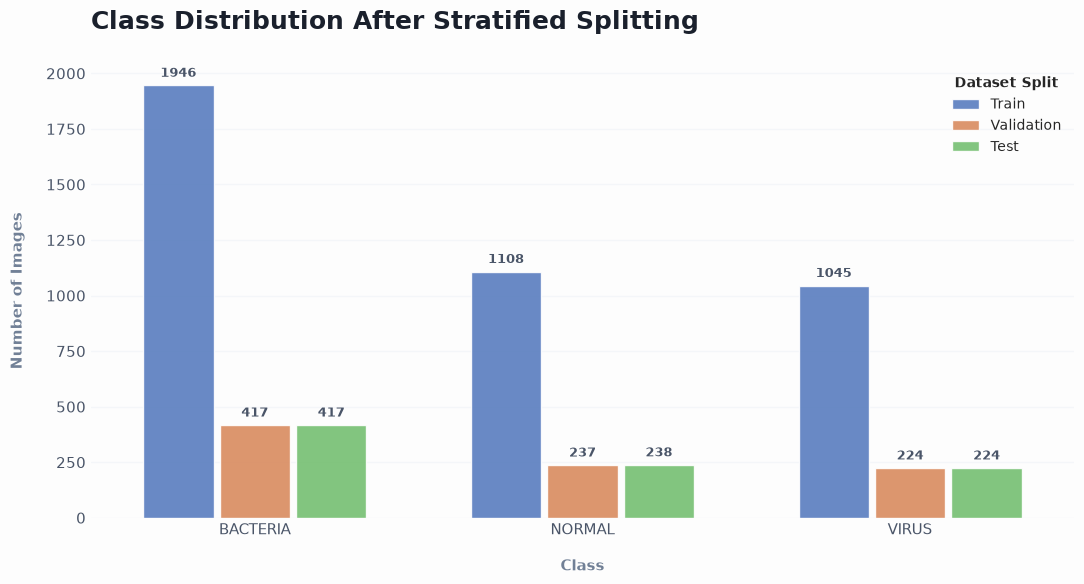

<Figure size 640x480 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean white background
sns.set_theme(style="white")

# Create figure with a premium layout
fig, ax = plt.subplots(figsize=(11, 6), facecolor="#fdfdfd")
ax.set_facecolor("#fdfdfd")

# Crisp, modern color palette for the splits
colors = sns.color_palette("muted", 3)

# Generate the grouped bar plot
ax = sns.barplot(
    data=plot_df,
    x="Class",
    y="Images",
    hue="Dataset",
    palette=colors,
    edgecolor=None,     # Removes harsh inner borders
    width=0.7,          # Controls total group width
    gap=0.08,           # Adds a tiny elegant gap between grouped bars
    alpha=0.9
)

# Automatically add labels on top of every bar
for container in ax.containers:
    ax.bar_label(
        container, 
        padding=4,      # Slightly tighter padding for grouped layouts
        fontsize=9,     # Smaller font so numbers don't overlap
        weight="bold", 
        color="#4a5568"
    )

# Premium Typography Setup
plt.title(
    "Class Distribution After Stratified Splitting",
    fontsize=18,
    weight="bold",
    pad=25,
    color="#1a202c",    
    loc="left"          
)

# Axis Configuration
plt.xlabel("Class", fontsize=11, labelpad=15, weight="bold", color="#718096")
plt.ylabel("Number of Images", fontsize=11, labelpad=15, weight="bold", color="#718096")

# Style the axis ticks
plt.xticks(fontsize=11, color="#4a5568")
plt.yticks(fontsize=11, color="#4a5568")

# Clean, minimalist legend placement
plt.legend(
    title="Dataset Split",
    title_fontproperties={"weight": "bold", "size": 10},
    frameon=False,      # Removes the box outline around the legend
    fontsize=10,
    loc="upper right"
)

# Remove all outer box borders completely
sns.despine(left=True, bottom=True)

# Add very subtle, clean horizontal lines
ax.yaxis.grid(True, linestyle="-", alpha=0.3, color="#e2e8f0")
ax.xaxis.grid(False)

# Remove the tick marks themselves
ax.tick_params(axis='both', which='both', length=0)

# Render cleanly
plt.tight_layout()
plt.show()


plt.tight_layout()

plt.show()

## Create Processed Dataset Structure

Create the directory structure for the processed multi-class dataset.

In [36]:
# ============================================================
# Create Processed Dataset Folder Structure
# ============================================================

import shutil

# Remove existing processed dataset (if any)
if PROCESSED_DATASET.exists():
    shutil.rmtree(PROCESSED_DATASET)

# Create folder structure
splits = ["train", "validation", "test"]
classes = ["NORMAL", "BACTERIA", "VIRUS"]

for split in splits:
    for cls in classes:
        (PROCESSED_DATASET / split / cls).mkdir(parents=True, exist_ok=True)

print("✅ Processed dataset folder structure created successfully.")

✅ Processed dataset folder structure created successfully.


## Copy Images to Processed Dataset

Copy images into the processed dataset according to the stratified train, validation, and test splits.

In [37]:
# ============================================================
# Copy Images to Processed Dataset
# ============================================================

from shutil import copy2

split_data = {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}

for split_name, df in split_data.items():

    for _, row in df.iterrows():

        destination = (
            PROCESSED_DATASET /
            split_name /
            row["label"] /
            row["filename"]
        )

        copy2(row["image_path"], destination)

print("✅ All images copied successfully.")

✅ All images copied successfully.


## Verify Processed Dataset

Verify the number of images in each class after dataset preparation.

In [38]:
# ============================================================
# Verify Processed Dataset
# ============================================================

verification = []

for split in ["train", "validation", "test"]:
    for cls in ["NORMAL", "BACTERIA", "VIRUS"]:

        folder = PROCESSED_DATASET / split / cls

        count = len(list(folder.glob("*")))

        verification.append({
            "Split": split,
            "Class": cls,
            "Images": count
        })

verification_df = pd.DataFrame(verification)

verification_df

,Split,Class,Images
0,train,NORMAL,1108
1,train,BACTERIA,1946
2,train,VIRUS,1045
3,validation,NORMAL,237
4,validation,BACTERIA,417
5,validation,VIRUS,224
6,test,NORMAL,238
7,test,BACTERIA,417
8,test,VIRUS,224


## Processed Dataset Summary

Summarize the final processed dataset before model training.

In [39]:
# ============================================================
# Final Dataset Summary
# ============================================================

summary = verification_df.pivot(
    index="Class",
    columns="Split",
    values="Images"
)

summary["Total"] = summary.sum(axis=1)

display(summary)

print("\nTotal Images :", summary["Total"].sum())

Split,test,train,validation,Total
Class,,,,
BACTERIA,417,1946,417,2780
NORMAL,238,1108,237,1583
VIRUS,224,1045,224,1493



Total Images : 5856


## Save Dataset Metadata

Save the dataset metadata and split information for reproducibility.

In [40]:
# ============================================================
# Save Metadata
# ============================================================

metadata.to_csv(
    PROCESSED_DATASET / "metadata.csv",
    index=False
)

train_df.to_csv(
    PROCESSED_DATASET / "train_metadata.csv",
    index=False
)

val_df.to_csv(
    PROCESSED_DATASET / "validation_metadata.csv",
    index=False
)

test_df.to_csv(
    PROCESSED_DATASET / "test_metadata.csv",
    index=False
)

print("✅ Metadata files saved successfully.")

✅ Metadata files saved successfully.


In [41]:
summary.to_csv(
    PROCESSED_DATASET / "dataset_summary.csv"
)

print("✅ Dataset summary saved.")

✅ Dataset summary saved.


In [42]:
from pathlib import Path

print(Path.cwd())

/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/notebooks


In [43]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path("/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI")

DATASET_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print(PROJECT_ROOT)
print(RESULTS_DIR)
print(MODELS_DIR)

/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI
/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/results
/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/models


In [44]:
plt.savefig(
    RESULTS_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Conclusion

The original Chest X-ray dataset has been successfully converted into a three-class dataset consisting of **NORMAL**, **BACTERIA**, and **VIRUS** classes.

### Completed Tasks

- Loaded the original dataset
- Identified bacterial and viral pneumonia images
- Merged all original dataset splits
- Performed a stratified 70/15/15 split
- Created the processed dataset directory structure
- Copied all images into their corresponding folders
- Verified the processed dataset

The processed dataset is now ready for model training.

**Next Notebook:** `03_Model_Training.ipynb`

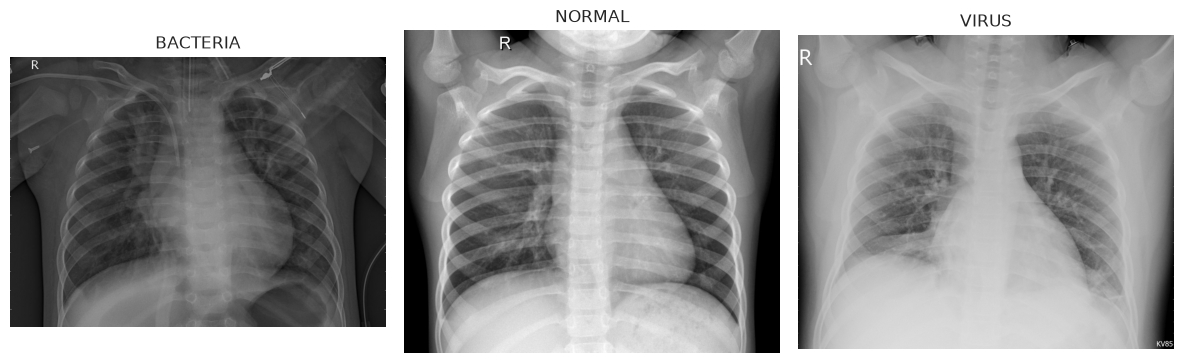

In [45]:
import matplotlib.pyplot as plt
from PIL import Image
import random, os

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
classes = ["BACTERIA", "NORMAL", "VIRUS"]
for i, cls in enumerate(classes):
    folder = PROCESSED_DATASET / "train" / cls   # PROCESSED_DATASET, DATASET_DIR না
    sample_file = random.choice(os.listdir(folder))
    img = Image.open(folder / sample_file)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=150)
plt.show()

In [1]:
!nvidia-smi




Fri Aug  7 19:50:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.57.01              KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050        On  |   00000000:10:00.0  On |                  N/A |
|  0%   46C    P8              8W /  130W |    1385MiB /   8192MiB |     10%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
print(sys.version)



3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]


In [3]:
import torch
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version for PyTorch:", torch.version.cuda)


PyTorch Version: 2.13.0+cu126
CUDA Available: True
CUDA Version for PyTorch: 12.6


In [4]:
!free -h


               total        used        free      shared  buff/cache   available
Mem:            13Gi       2.7Gi       8.6Gi       3.5Mi       2.5Gi        10Gi
Swap:          4.0Gi          0B       4.0Gi
